# CompareAtlases: Cell x Gene Explorer

This notebook loads atlas/HCR cell x gene tables created by `run_collect_reference_atlas_cellxgene.py`,
lets you choose a custom gene order, and replots using `aind_hcr_qc.viz.plot_cell_x_gene_clustered`.

## How to use
1. Run the import/helpers cell.
2. Run the discovery cell to list available `cell_x_gene.csv` files.
3. In the parameter cell, set `TABLE_KEY` and `GENE_ORDER_TEXT`.
4. Run the plotting cell to generate clustered cell x gene plots.
5. Optional: set `SAVE_REORDERED_CSV = True` to write a reordered CSV.

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import aind_hcr_qc.viz as viz

REFERENCE_ROOT = Path("/root/capsule/scratch/reference_atlas_cellxgene")


def discover_cellxgene_tables(root: Path = REFERENCE_ROOT) -> dict[str, Path]:
    """Find all generated cell_x_gene.csv tables under the reference output root."""
    tables: dict[str, Path] = {}
    for csv_path in sorted(root.glob("**/cell_x_gene.csv")):
        rel_parent = csv_path.parent.relative_to(root).as_posix()
        key = rel_parent if rel_parent != "." else "root"
        tables[key] = csv_path
    return tables


def load_cellxgene_table(table_path: Path) -> pd.DataFrame:
    return pd.read_csv(table_path, index_col=0)


def parse_gene_order(
    gene_text: str,
    available_genes: list[str],
    append_missing: bool = True,
) -> tuple[list[str], list[str]]:
    requested = [g.strip() for g in gene_text.replace("\n", ",").split(",") if g.strip()]
    requested = list(dict.fromkeys(requested))

    if not requested:
        return available_genes.copy(), []

    present = [g for g in requested if g in available_genes]
    missing = [g for g in requested if g not in available_genes]

    if append_missing:
        remaining = [g for g in available_genes if g not in present]
        ordered = present + remaining
    else:
        ordered = present

    return ordered, missing


def subset_and_order_genes(
    cxg: pd.DataFrame,
    gene_text: str,
    append_missing: bool = True,
) -> tuple[pd.DataFrame, list[str]]:
    available = cxg.columns.astype(str).tolist()
    ordered_genes, missing = parse_gene_order(
        gene_text,
        available,
        append_missing=append_missing,
    )
    if not ordered_genes:
        raise ValueError("No genes left after applying gene order filter.")
    return cxg.loc[:, ordered_genes].copy(), missing


def maybe_subsample_cells(cxg: pd.DataFrame, max_cells: int, random_seed: int) -> pd.DataFrame:
    if max_cells > 0 and len(cxg) > max_cells:
        return cxg.sample(n=max_cells, random_state=random_seed)
    return cxg


def normalize_cxg(cxg: pd.DataFrame, transform: str) -> pd.DataFrame:
    """Apply a normalization transform to a cells x genes matrix.

    Supported transforms
    --------------------
    "none"        : return as-is (data already log-scaled, e.g. ABC Atlas log2)
    "log1p"       : log(x+1) on raw counts  (HCR spot counts)
    "cp10k_log1p" : CP10K library-size normalize, then log(x+1)  (Smart-seq / TASIC)
    """
    if transform == "none":
        return cxg.copy()
    elif transform == "log1p":
        return pd.DataFrame(
            np.log1p(cxg.values.astype(float)),
            index=cxg.index,
            columns=cxg.columns,
        )
    elif transform == "cp10k_log1p":
        lib = cxg.sum(axis=1).replace(0, np.nan)
        cpm = cxg.div(lib, axis=0).mul(10_000).fillna(0)
        return pd.DataFrame(
            np.log1p(cpm.values.astype(float)),
            index=cpm.index,
            columns=cpm.columns,
        )
    else:
        raise ValueError(
            f"Unknown transform: {transform!r}. "
            "Choose from: 'none', 'log1p', 'cp10k_log1p'."
        )


def zscore_cxg(cxg: pd.DataFrame) -> pd.DataFrame:
    """Gene-wise z-score: subtract mean and divide by std across all cells."""
    arr = cxg.values.astype(float)
    means = arr.mean(axis=0)
    stds = arr.std(axis=0)
    stds[stds < 1e-12] = 1.0  # avoid division by zero for constant genes
    return pd.DataFrame(
        (arr - means) / stds,
        index=cxg.index,
        columns=cxg.columns,
    )


def plot_clustered_with_viz(
    cxg: pd.DataFrame,
    title: str,
    k: int = 20,
    clip_max: float = 200.0,
    fig_size: tuple[float, float] | None = None,
    cluster_method: str = "kmeans",
    cluster_sort_gene: str = "Gad2",
    add_cluster_labels: bool = False,
):
    if fig_size is None:
        n_cells, n_genes = cxg.shape
        fig_w = float(np.clip(4.0 + 0.06 * n_genes, 8.0, 42.0))
        fig_h = float(np.clip(4.0 + 0.015 * n_cells, 8.0, 48.0))
        fig_size = (fig_w, fig_h)

    fig, cluster_labels, sorted_cell_ids = viz.plot_cell_x_gene_clustered(
        cxg,
        clip_range=(0, clip_max),
        fig_size=fig_size,
        k=k,
        cluster_method=cluster_method,
        add_cluster_labels=add_cluster_labels,
        title=title,
        gene_sort=None,
        cluster_sort_gene=cluster_sort_gene,
    )
    plt.show()
    return fig, cluster_labels, sorted_cell_ids


def cluster_cells_with_viz(
    cxg: pd.DataFrame,
    k: int = 24,
    cluster_method: str = "kmeans",
    cluster_sort_gene: str = "Gad2",
) -> pd.Series:
    """Cluster cells and return labels aligned to the original row index.

    clip_range is set to (-inf, inf) so z-scored data passes through unclipped.
    The figure is closed immediately; only cluster labels are used.
    """
    fig, cluster_labels, sorted_cell_ids = viz.plot_cell_x_gene_clustered(
        cxg,
        clip_range=(-np.inf, np.inf),
        fig_size=(4, 4),
        k=k,
        cluster_method=cluster_method,
        add_cluster_labels=False,
        title=None,
        gene_sort=None,
        cluster_sort_gene=cluster_sort_gene,
    )
    plt.close(fig)

    labels = pd.Series(cluster_labels, index=sorted_cell_ids, name="cluster")
    labels = labels.reindex(cxg.index)
    if labels.isna().any():
        raise RuntimeError("Cluster labels could not be aligned back to all cells.")
    return labels.astype(int)


def compute_cluster_centroids(cxg: pd.DataFrame, labels: pd.Series) -> pd.DataFrame:
    labels = labels.reindex(cxg.index)
    return cxg.groupby(labels).mean()


def _resolve_marker_gene(columns: list[str], candidates: list[str]) -> str | None:
    lookup = {c.lower(): c for c in columns}
    for gene in candidates:
        key = gene.lower()
        if key in lookup:
            return lookup[key]
    return None


def build_reference_cluster_order(
    reference_centroids: pd.DataFrame,
    subclass_order: tuple[str, ...] = ("VIP", "LAMP5", "SST", "PV"),
) -> tuple[list[int], pd.DataFrame]:
    marker_map = {
        "VIP":   _resolve_marker_gene(reference_centroids.columns.tolist(), ["Vip", "VIP"]),
        "LAMP5": _resolve_marker_gene(reference_centroids.columns.tolist(), ["Lamp5", "LAMP5"]),
        "SST":   _resolve_marker_gene(reference_centroids.columns.tolist(), ["Sst", "SST"]),
        "PV":    _resolve_marker_gene(reference_centroids.columns.tolist(), ["Pvalb", "PV"]),
    }
    priority = {name: i for i, name in enumerate(subclass_order)}
    other_priority = len(subclass_order)

    rows = []
    for cluster_id, row in reference_centroids.iterrows():
        scores = {}
        for subclass, gene in marker_map.items():
            scores[subclass] = float(row[gene]) if gene is not None else -np.inf

        best_subclass = max(scores, key=scores.get) if scores else "OTHER"
        best_score = scores.get(best_subclass, -np.inf)
        if not np.isfinite(best_score):
            best_subclass = "OTHER"
            best_score = -np.inf

        rows.append(
            {
                "cluster": int(cluster_id),
                "subclass": best_subclass,
                "marker_score": best_score,
                "priority": priority.get(best_subclass, other_priority),
            }
        )

    cluster_meta = pd.DataFrame(rows).sort_values(
        ["priority", "marker_score", "cluster"],
        ascending=[True, False, True],
        kind="mergesort",
    )
    ordered_clusters = cluster_meta["cluster"].astype(int).tolist()
    return ordered_clusters, cluster_meta


def _cosine_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a_norm = np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = np.linalg.norm(b, axis=1, keepdims=True)
    denom = np.clip(a_norm * b_norm.T, a_min=1e-12, a_max=None)
    return (a @ b.T) / denom


def match_clusters_to_reference(
    reference_centroids: pd.DataFrame,
    other_centroids: pd.DataFrame,
    ordered_reference_clusters: list[int],
    reference_cluster_meta: pd.DataFrame,
    min_shared_genes: int = 5,
) -> pd.DataFrame:
    shared_genes = [g for g in reference_centroids.columns if g in other_centroids.columns]
    if len(shared_genes) < min_shared_genes:
        raise ValueError(
            f"Need at least {min_shared_genes} shared genes for centroid matching; got {len(shared_genes)}."
        )

    reference_centroids = reference_centroids.loc[ordered_reference_clusters, shared_genes]
    other_centroids = other_centroids.loc[:, shared_genes]

    sim = _cosine_similarity_matrix(reference_centroids.to_numpy(), other_centroids.to_numpy())
    best_ref_idx = sim.argmax(axis=0)

    rank_map = {cluster: rank for rank, cluster in enumerate(ordered_reference_clusters)}
    subclass_map = reference_cluster_meta.set_index("cluster")["subclass"].to_dict()

    rows = []
    for j, other_cluster in enumerate(other_centroids.index):
        ref_cluster = int(ordered_reference_clusters[int(best_ref_idx[j])])
        rows.append(
            {
                "other_cluster": int(other_cluster),
                "matched_reference_cluster": ref_cluster,
                "reference_rank": int(rank_map[ref_cluster]),
                "reference_subclass": str(subclass_map.get(ref_cluster, "OTHER")),
                "similarity": float(sim[int(best_ref_idx[j]), j]),
            }
        )

    mapping = pd.DataFrame(rows).sort_values(
        ["reference_rank", "similarity", "other_cluster"],
        ascending=[True, False, True],
        kind="mergesort",
    )
    return mapping


def map_and_reorder_other_by_reference(
    reference_cxg: pd.DataFrame,
    other_cxg: pd.DataFrame,
    k: int = 24,
    cluster_method: str = "kmeans",
    cluster_sort_gene: str = "Gad2",
    reference_labels: pd.Series | None = None,
    reference_cluster_order: list[int] | None = None,
    reference_cluster_meta: pd.DataFrame | None = None,
    reference_cxg_for_clustering: pd.DataFrame | None = None,
    other_cxg_for_clustering: pd.DataFrame | None = None,
) -> dict[str, object]:
    # Use clustering-specific matrices if provided; fall back to the plot matrices.
    ref_clust = reference_cxg_for_clustering if reference_cxg_for_clustering is not None else reference_cxg
    oth_clust = other_cxg_for_clustering if other_cxg_for_clustering is not None else other_cxg

    if reference_labels is None:
        reference_labels = cluster_cells_with_viz(
            ref_clust,
            k=k,
            cluster_method=cluster_method,
            cluster_sort_gene=cluster_sort_gene,
        )
    other_labels = cluster_cells_with_viz(
        oth_clust,
        k=k,
        cluster_method=cluster_method,
        cluster_sort_gene=cluster_sort_gene,
    )

    reference_centroids = compute_cluster_centroids(ref_clust, reference_labels)
    other_centroids = compute_cluster_centroids(oth_clust, other_labels)

    if reference_cluster_order is None or reference_cluster_meta is None:
        reference_cluster_order, reference_cluster_meta = build_reference_cluster_order(reference_centroids)

    mapping = match_clusters_to_reference(
        reference_centroids=reference_centroids,
        other_centroids=other_centroids,
        ordered_reference_clusters=reference_cluster_order,
        reference_cluster_meta=reference_cluster_meta,
    )

    matched_ref = mapping.set_index("other_cluster")["matched_reference_cluster"].to_dict()
    matched_subclass = mapping.set_index("other_cluster")["reference_subclass"].to_dict()
    matched_rank = mapping.set_index("other_cluster")["reference_rank"].to_dict()

    mapped_labels = other_labels.map(
        lambda c: f"{matched_rank[int(c)]:02d}-{matched_subclass[int(c)]}-ref{matched_ref[int(c)]}-src{int(c)}"
    )

    sorted_index = mapped_labels.sort_values(kind="mergesort").index
    other_reordered = other_cxg.loc[sorted_index].copy()
    mapped_labels_reordered = mapped_labels.loc[sorted_index].copy()

    return {
        "reference_labels": reference_labels,
        "other_labels": other_labels,
        "reference_centroids": reference_centroids,
        "other_centroids": other_centroids,
        "reference_cluster_order": reference_cluster_order,
        "reference_cluster_meta": reference_cluster_meta,
        "mapping": mapping,
        "mapped_labels_reordered": mapped_labels_reordered,
        "other_reordered": other_reordered,
    }

In [24]:
tables = discover_cellxgene_tables()

print(f"Reference root: {REFERENCE_ROOT}")
print(f"Found {len(tables)} table(s).")
for key, path in tables.items():
    print(f"- {key}: {path}")

if not tables:
    print("No tables found. Run run_collect_reference_atlas_cellxgene.py first.")

Reference root: /root/capsule/scratch/reference_atlas_cellxgene
Found 4 table(s).
- 10x-hmb: /root/capsule/scratch/reference_atlas_cellxgene/10x-hmb/cell_x_gene.csv
- hcr/790322: /root/capsule/scratch/reference_atlas_cellxgene/hcr/790322/cell_x_gene.csv
- merfish: /root/capsule/scratch/reference_atlas_cellxgene/merfish/cell_x_gene.csv
- tasic: /root/capsule/scratch/reference_atlas_cellxgene/tasic/cell_x_gene.csv


In [25]:
GENE_ORDER = [
    "Gad2",
    "Slc17a7",
    "Calb1",
    "Calb2",
    "Cck",
    "Chat",
    "Crh",
    "Hpse",
    "Mme",
    "Ndnf",
    "Npy",
    "Pdyn",
    "Penk",
    "Pthlh",
    "Tac1",
    "Tac2",
    "Reln",
    "Lamp5",
    "Pvalb",
    "Sst",
    "Vip",
]

# Convert to the format expected by parse_gene_order().
GENE_ORDER_TEXT = "\n".join(GENE_ORDER)
print(f"Gene order set with {len(GENE_ORDER)} genes.")

Gene order set with 21 genes.


Table key: 10x-hmb
Source: /root/capsule/scratch/reference_atlas_cellxgene/10x-hmb/cell_x_gene.csv
Raw shape: 47,030 cells x 21 genes
Plot shape: 12,000 cells x 21 genes


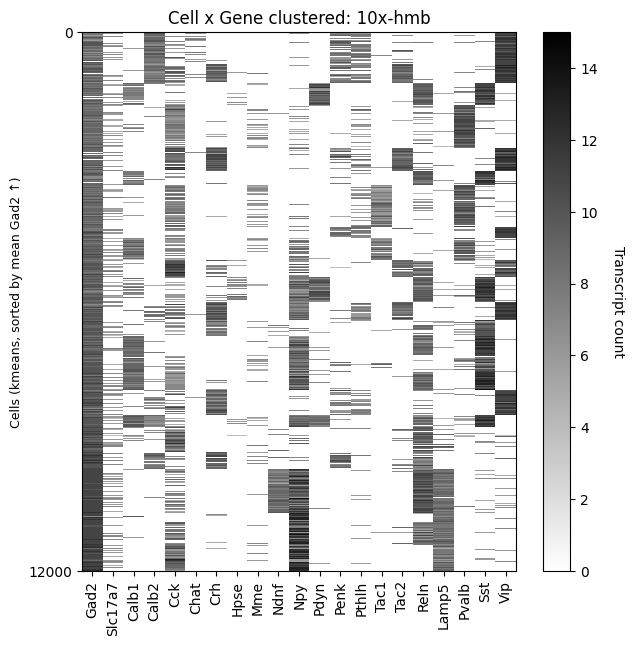

In [6]:
if not tables:
    raise RuntimeError("No cell_x_gene tables discovered. Run the discovery cell after generating data.")

# Set these parameters, then run this cell.
TABLE_KEY = "10x-hmb"
GENE_ORDER_TEXT = "\n".join(GENE_ORDER)  # Uses the gene ordering cell above.
APPEND_MISSING_GENES = True

MAX_CELLS = 12000
RANDOM_SEED = 42

K = 24
CLIP_MAX = 3000.0
CLUSTER_METHOD = "kmeans"  # kmeans, agglomerative, ward_leaf
CLUSTER_SORT_GENE = "Gad2"
SHOW_CLUSTER_LABELS = False  # Set True to show cluster lines/labels.

SAVE_REORDERED_CSV = False
SAVE_FILENAME = "cell_x_gene_reordered.csv"

print(f"Table key: {TABLE_KEY}")
print(f"Source: {tables[TABLE_KEY]}")

cxg_raw = load_cellxgene_table(tables[TABLE_KEY])
print(f"Raw shape: {cxg_raw.shape[0]:,} cells x {cxg_raw.shape[1]:,} genes")

cxg_ordered, missing_genes = subset_and_order_genes(
    cxg_raw,
    GENE_ORDER_TEXT,
    append_missing=APPEND_MISSING_GENES,
)

if missing_genes:
    print(f"Missing genes skipped: {missing_genes}")

cxg_plot = maybe_subsample_cells(cxg_ordered, max_cells=MAX_CELLS, random_seed=RANDOM_SEED)
print(f"Plot shape: {cxg_plot.shape[0]:,} cells x {cxg_plot.shape[1]:,} genes")

fig, cluster_labels, sorted_cell_ids = plot_clustered_with_viz(
    cxg_plot,
    title=f"Cell x Gene clustered: {TABLE_KEY}",
    k=K,
    clip_max=CLIP_MAX,
    cluster_method=CLUSTER_METHOD,
    cluster_sort_gene=CLUSTER_SORT_GENE,
    add_cluster_labels=SHOW_CLUSTER_LABELS,
    fig_size=(7, 7),
)

if SAVE_REORDERED_CSV:
    out_path = tables[TABLE_KEY].parent / SAVE_FILENAME
    cxg_ordered.to_csv(out_path)
    print(f"Saved reordered CSV: {out_path}")


[10x-hmb] raw=(47030, 21), plot=(12000, 21), transform=none

[hcr/790322] raw=(7674, 21), plot=(7674, 21), transform=log1p

[merfish] raw=(4301, 14), plot=(4301, 14), transform=none
Missing genes skipped: ['Cck', 'Hpse', 'Mme', 'Npy', 'Pthlh', 'Tac1', 'Sst']

[tasic] raw=(5331, 21), plot=(5331, 21), transform=cp10k_log1p

Reference pseudo-hierarchical order:
 cluster subclass  marker_score
       3      VIP      1.583613
       1      VIP      1.553869
       0      VIP      1.524051
       5      VIP      1.511151
      10      VIP      1.505536
       2      VIP      1.499506
       4      VIP      1.305406
      15      VIP     -0.016572
      21    LAMP5      2.121257
      22    LAMP5      1.999782
      13    LAMP5      1.715490
      23    LAMP5      0.908478
       7      SST      1.705753
       9      SST      1.635313
       8      SST      1.584176
       6      SST      1.569215
      18      SST      1.561438
      17       PV      2.027316
      16       PV      1.74819

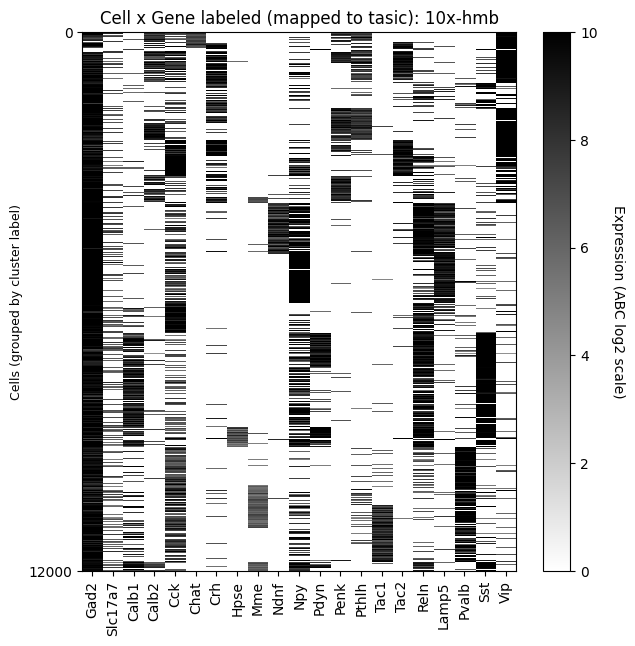


[hcr/790322] centroid matches (top 10):
 other_cluster  matched_reference_cluster  reference_rank reference_subclass  similarity
             2                          0               2                VIP    0.941074
             5                          5               3                VIP    0.894562
             9                         10               4                VIP    0.903531
             4                          2               5                VIP    0.868328
             3                          2               5                VIP    0.655949
            10                          4               6                VIP    0.874407
            22                         21               8              LAMP5    0.848534
            23                         13              10              LAMP5    0.834720
             7                         13              10              LAMP5    0.375447
            18                         23              11            

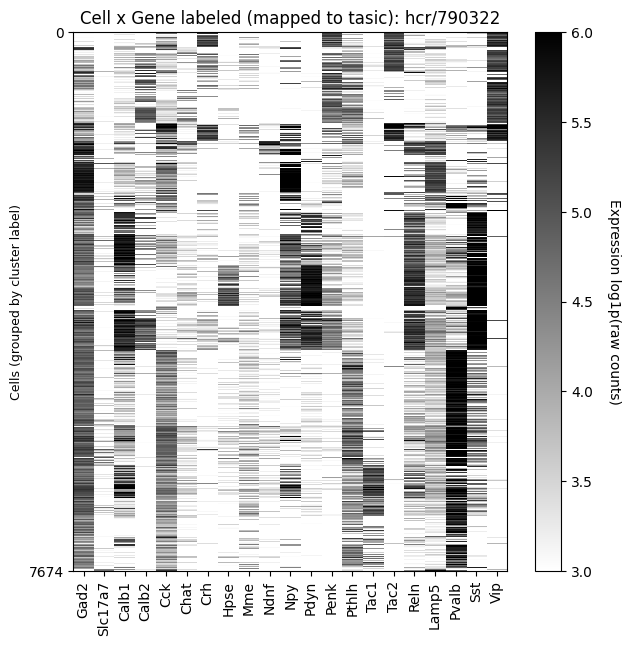


[merfish] centroid matches (top 10):
 other_cluster  matched_reference_cluster  reference_rank reference_subclass  similarity
             4                          3               0                VIP    0.981379
             0                          3               0                VIP    0.866859
             3                          1               1                VIP    0.948778
             6                          5               3                VIP    0.922902
             9                         10               4                VIP    0.936275
             5                          2               5                VIP    0.895316
             2                          4               6                VIP    0.968907
            21                         15               7                VIP    0.958154
            22                         21               8              LAMP5    0.968421
            13                         21               8              L

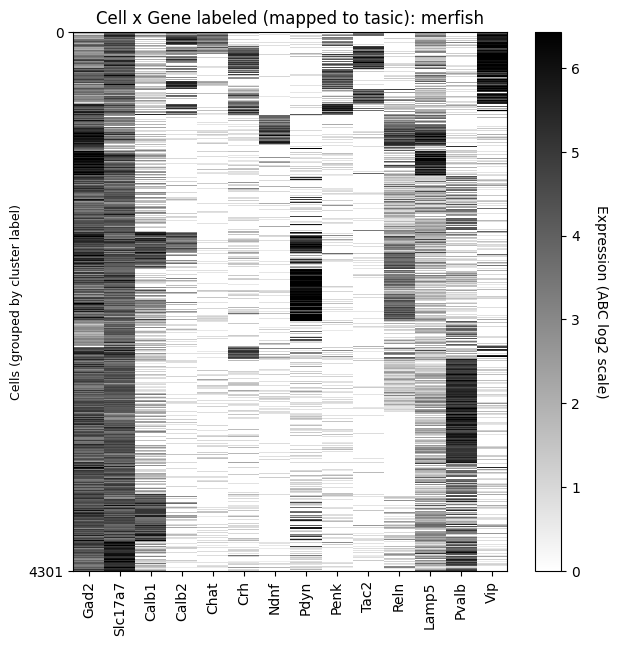


[tasic] centroid matches (top 10):
 other_cluster  matched_reference_cluster  reference_rank reference_subclass  similarity
             3                          3               0                VIP         1.0
             1                          1               1                VIP         1.0
             0                          0               2                VIP         1.0
             5                          5               3                VIP         1.0
            10                         10               4                VIP         1.0
             2                          2               5                VIP         1.0
             4                          4               6                VIP         1.0
            15                         15               7                VIP         1.0
            21                         21               8              LAMP5         1.0
            22                         22               9              LAM

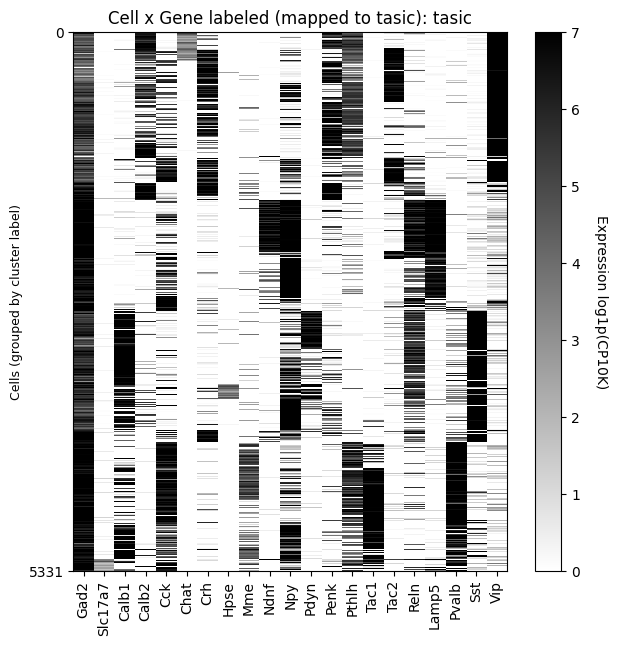

In [31]:
# Optional: compare multiple tables with pseudo-hierarchical mapping to a reference.
SELECTED_KEYS = list(tables.keys())
REFERENCE_KEY = "tasic"
GENE_ORDER_TEXT_MULTI = "\n".join(GENE_ORDER)
SHOW_CLUSTER_LABELS_MULTI = False  # Set True to show cluster lines/labels.

NORMALIZATION_MAP = {
    "hcr/790322": "log1p",        # raw spot counts -> log1p
    "tasic": "cp10k_log1p",       # raw Smart-seq counts -> CP10K + log1p
    "merfish": "none",            # ABC matrix already log2-scaled
    "10x-hmb": "none",            # ABC matrix already log2-scaled
}

USE_ZSCORE_FOR_MATCHING = True
UNZSCORE_BEFORE_PLOTTING = True  # if True, plot log-like normalized values instead of z-scores

# Per-dataset clip overrides for plotting. Any dataset not listed uses auto clip.
CLIP_RANGE_MAP = {
    "hcr/790322": (3.0, 6.0),
    "10x-hmb": (0.0, 10.0),
    "tasic": (0.0, 7.0),
}

if REFERENCE_KEY not in SELECTED_KEYS:
    raise ValueError(f"REFERENCE_KEY={REFERENCE_KEY} not in SELECTED_KEYS.")

# Fill any missing table keys with "none" by default.
for _k in SELECTED_KEYS:
    NORMALIZATION_MAP.setdefault(_k, "none")

raw_data = {}
norm_data = {}
zscore_data = {}

for table_key in SELECTED_KEYS:
    cxg_raw = load_cellxgene_table(tables[table_key])
    cxg_ordered, missing = subset_and_order_genes(
        cxg_raw,
        GENE_ORDER_TEXT_MULTI,
        append_missing=True,
    )
    cxg_plot = maybe_subsample_cells(cxg_ordered, max_cells=MAX_CELLS, random_seed=RANDOM_SEED)

    transform = NORMALIZATION_MAP[table_key]
    cxg_norm = normalize_cxg(cxg_plot, transform=transform)
    cxg_z = zscore_cxg(cxg_norm)

    raw_data[table_key] = cxg_plot
    norm_data[table_key] = cxg_norm
    zscore_data[table_key] = cxg_z

    print(f"\n[{table_key}] raw={cxg_raw.shape}, plot={cxg_plot.shape}, transform={transform}")
    if missing:
        print(f"Missing genes skipped: {missing}")

# Matrices for clustering/matching vs plotting.
match_data = zscore_data if USE_ZSCORE_FOR_MATCHING else norm_data
plot_data = norm_data if UNZSCORE_BEFORE_PLOTTING else match_data


def _auto_clip_range(df: pd.DataFrame, use_zscore_scale: bool) -> tuple[float, float]:
    arr = np.asarray(df.values, dtype=float)
    if use_zscore_scale:
        return (-3.0, 3.0)
    lo = float(np.nanpercentile(arr, 1.0))
    hi = float(np.nanpercentile(arr, 99.0))
    lo = max(0.0, lo)
    if hi <= lo:
        hi = lo + 1.0
    return (lo, hi)


def _cbar_label_for(table_key: str) -> str:
    if not UNZSCORE_BEFORE_PLOTTING and USE_ZSCORE_FOR_MATCHING:
        return "Expression z-score"

    transform = NORMALIZATION_MAP[table_key]
    if transform == "none":
        return "Expression (ABC log2 scale)"
    if transform == "log1p":
        return "Expression log1p(raw counts)"
    if transform == "cp10k_log1p":
        return "Expression log1p(CP10K)"
    return f"Expression ({transform})"


reference_cxg_for_matching = match_data[REFERENCE_KEY]
reference_cxg_for_plot = plot_data[REFERENCE_KEY]

reference_clusters = cluster_cells_with_viz(
    reference_cxg_for_matching,
    k=K,
    cluster_method=CLUSTER_METHOD,
    cluster_sort_gene=CLUSTER_SORT_GENE,
 )
reference_centroids = compute_cluster_centroids(reference_cxg_for_matching, reference_clusters)
reference_cluster_order, reference_cluster_meta = build_reference_cluster_order(reference_centroids)

print("\nReference pseudo-hierarchical order:")
print(reference_cluster_meta[["cluster", "subclass", "marker_score"]].to_string(index=False))
print(f"\nUSE_ZSCORE_FOR_MATCHING={USE_ZSCORE_FOR_MATCHING}, UNZSCORE_BEFORE_PLOTTING={UNZSCORE_BEFORE_PLOTTING}")

for table_key in SELECTED_KEYS:
    result = map_and_reorder_other_by_reference(
        reference_cxg=reference_cxg_for_plot,
        other_cxg=plot_data[table_key],
        k=K,
        cluster_method=CLUSTER_METHOD,
        cluster_sort_gene=CLUSTER_SORT_GENE,
        reference_labels=reference_clusters,
        reference_cluster_order=reference_cluster_order,
        reference_cluster_meta=reference_cluster_meta,
        reference_cxg_for_clustering=reference_cxg_for_matching,
        other_cxg_for_clustering=match_data[table_key],
    )

    mapping = result["mapping"]
    print(f"\n[{table_key}] centroid matches (top 10):")
    print(mapping.head(10).to_string(index=False))

    use_zscore_scale = (not UNZSCORE_BEFORE_PLOTTING) and USE_ZSCORE_FOR_MATCHING
    clip_low, clip_high = CLIP_RANGE_MAP.get(
        table_key,
        _auto_clip_range(result["other_reordered"], use_zscore_scale=use_zscore_scale),
    )
    print(f"[{table_key}] clip_range=({clip_low:.2f}, {clip_high:.2f}), cbar={_cbar_label_for(table_key)}")

    fig, sorted_labels, sorted_cell_ids = viz.plot_cell_x_gene_labeled(
        result["other_reordered"],
        labels=result["mapped_labels_reordered"],
        clip_range=(clip_low, clip_high),
        fig_size=(7, 7),
        add_cluster_labels=SHOW_CLUSTER_LABELS_MULTI,
        cbar_label=_cbar_label_for(table_key),
        title=f"Cell x Gene labeled (mapped to {REFERENCE_KEY}): {table_key}",
        gene_sort=None,
    )
    plt.show()

In [28]:
# Summary: which source clusters map to which reference clusters within each subclass.
mapping_summary = {}

for table_key in SELECTED_KEYS:
    result = map_and_reorder_other_by_reference(
        reference_cxg=plot_data[REFERENCE_KEY],
        other_cxg=plot_data[table_key],
        k=K,
        cluster_method=CLUSTER_METHOD,
        cluster_sort_gene=CLUSTER_SORT_GENE,
        reference_labels=reference_clusters,
        reference_cluster_order=reference_cluster_order,
        reference_cluster_meta=reference_cluster_meta,
        reference_cxg_for_clustering=match_data[REFERENCE_KEY],
        other_cxg_for_clustering=match_data[table_key],
    )
    mapping = result["mapping"].copy()
    mapping_summary[table_key] = mapping

    grouped = (
        mapping.groupby(["reference_subclass", "matched_reference_cluster"], as_index=False)
        .agg(
            source_clusters=("other_cluster", lambda s: sorted(map(int, s.tolist()))),
            n_source_clusters=("other_cluster", "size"),
            mean_similarity=("similarity", "mean"),
            min_similarity=("similarity", "min"),
        )
        .sort_values(["reference_subclass", "matched_reference_cluster"])
    )

    print(f"\n=== {table_key} -> reference {REFERENCE_KEY} ===")
    for subclass in ["VIP", "LAMP5", "SST", "PV", "OTHER"]:
        part = grouped[grouped["reference_subclass"] == subclass]
        if part.empty:
            continue
        print(f"\n{subclass}")
        print(part.to_string(index=False))


=== 10x-hmb -> reference tasic ===

VIP
reference_subclass  matched_reference_cluster source_clusters  n_source_clusters  mean_similarity  min_similarity
               VIP                          0             [0]                  1         0.573751        0.573751
               VIP                          1          [1, 3]                  2         0.886793        0.823770
               VIP                          2             [4]                  1         0.955062        0.955062
               VIP                          3             [2]                  1         0.983056        0.983056
               VIP                          4         [7, 10]                  2         0.925199        0.914426
               VIP                          5          [5, 9]                  2         0.905406        0.857330
               VIP                         10        [16, 18]                  2         0.757982        0.592717
               VIP                         15  